# Plot variables for Taylor Diagrams
- This script is used to plot variables from simulations and Taylor Diagram metrics;
- Simulations: TRAF and sensitity simulations at FR-Capitole and UK-Manchester. 

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cftime
import string
import matplotlib.dates as mdates
import geocat.viz as gv
from matplotlib.lines import Line2D
import string

In [2]:
labelfont = 14
linewidth = 1
labelcolor = '#6b6b6b'
padding = 8
pad = 1
xwidth = 1
length = 1
maintitles = ['LWup', 'Qh', 'Qle', 'Qtau']
lc1 = '#e41a1c'
lc2 = '#377eb8'
lc3 = '#4daf4a'
lc4 = '#984ea3'
lc5 = '#66a61e'
lc6 = '#a65628'

case_index = 'Index'
site_index = 'site'
var_index = 'Variable'
data_list = []
alpha = 0.5
season_list = ['summer', 'winter']
site_list = ['FR-Capitole']
factor_list1 = ['add0.1', 'add0.2', 'add0.4', 'add0.8', 'sub0.1', 'sub0.2', 'sub0.4', 'sub0.8']
factor_list2 = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
target_list = ['AADT', r'$p_{v}$']
var_index='var'
case_index='factor'
markerline = 0.5
nrow = 1
ncol = 2
var_list = [r'$LW_\mathrm{up}$', r'$Q_\mathrm{h}$', r'$Q_\mathrm{le}$', 
                  r'$Q_\mathrm{tau}$']
facecolors = 'none'                 
markerfacecolor='none'

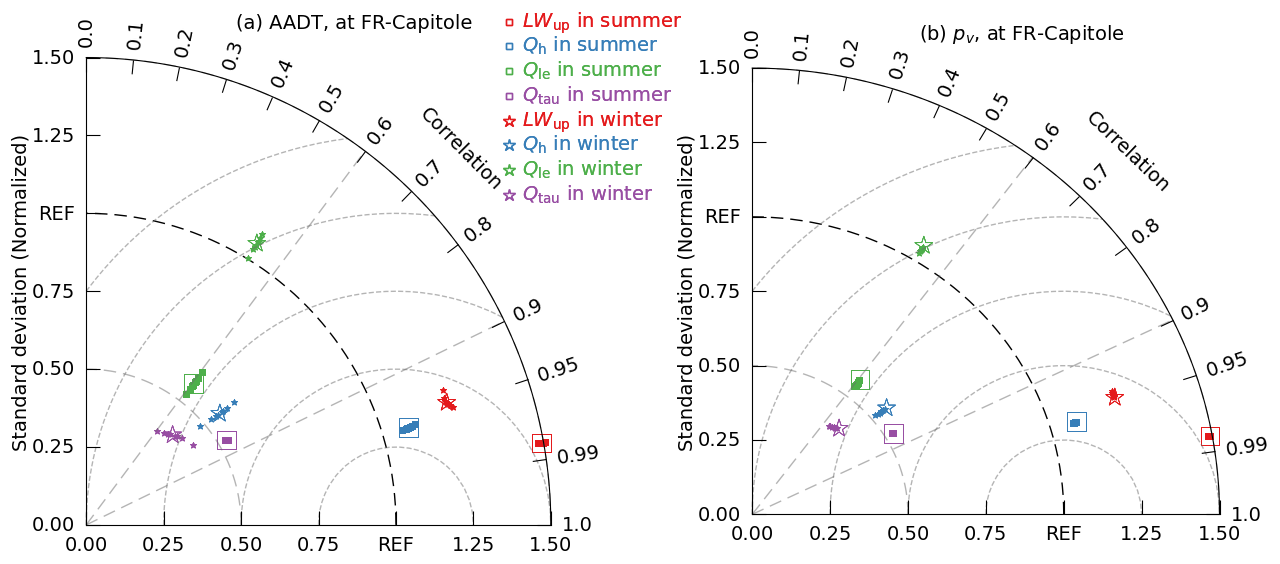

In [3]:
label_xloc = 0.4
label_yloc = 0.98
line=0.045
fig = plt.figure(figsize=(13, 5.5))
for i in range(nrow * ncol):
    index_row = i // ncol
    site = site_list[0]
    colors = [lc1, lc2, lc3, lc4]
    std_range = 1.5
    da = gv.TaylorDiagram(refstd=1, fig=fig, rect=121+i, label='REF', std_range=(0, std_range))
    da.set_fontsizes_and_pad(ticklabel_fontsize = labelfont, axislabel_fontsize=labelfont, axislabel_pad = 1)
    da.add_std_grid(np.array([0.5, 1.5]), color=labelcolor, linewidth=xwidth, alpha=alpha)
    da.add_corr_grid(np.array([0.6, 0.9]), color=labelcolor,linewidth=xwidth, alpha=alpha)
    da.add_contours(levels=np.arange(0, 1.5, 0.25), colors=labelcolor, linewidths=xwidth, alpha=alpha, **{'linestyles': '--'}) 
    title_name = f'({string.ascii_lowercase[i]}) {target_list[i]}, at {site}' 
    da.add_title(title_name, fontsize=labelfont, x=0.575, y_loc=1.035)
    offset=line*len(var_list)
    for s in range(2):
        season = season_list[s]
        if i ==0:
            df_result = pd.read_csv(f'../../sensitivity/taylor_diagram/data_for_figure/{site}_{season}_std_coef.csv')
        else:
            df_result = pd.read_csv(f'../taylor_diagram/data_for_figure/{site}_{season}_std_coef.csv')
        for case in range(2):
            if case ==0:
                result = df_result[df_result['factor']=='traffic']
                #annotate_on = True
                annotate_on = False
                markersize= 180
                #facecolors = 'none'
            else:    
                result = df_result[df_result['factor']!='traffic']
                annotate_on = False
                markersize= 20
            std_pivot_df = result.pivot(index=var_index, columns=case_index, values='sdev')
            cof_pivot_df = result.pivot(index=var_index, columns=case_index, values='coef')
            stddev = std_pivot_df.to_numpy()
            corrcoef = cof_pivot_df.to_numpy()
            for j in range(stddev.shape[0]): 
                color = colors[j]
                if case ==0:
                    facecolors = 'none'
                else:
                    facecolors = color    
                if s == 0:
                    marker='s'
                else: 
                    #marker='d'
                    marker='*' 
                for m in range(stddev.shape[0]):
                    da.add_model_set(stddev[j],
                         corrcoef[j],
                         #xytext=(-13.5, 24.5), # marker label location, in pixels
                         xytext=(8, 8),
                         fontsize=labelfont-2,
                         color=color, # label color
                         annotate_on=annotate_on,
                         #label='Baseline',
                         facecolors=facecolors,
                         s=markersize,
                         linewidth=markerline,
                         marker=marker)
        for q, var in enumerate(var_list):
            if s==0:
                #markerfacecolor='none'
                marker='s'
                legend_markersize=5
            else:
                #markerfacecolor=colors[q]   
                marker='*'
                legend_markersize=9
            fig.add_artist(Line2D([label_xloc], [label_yloc-offset*s - (line * q)], marker=marker, markersize=legend_markersize,
                          markeredgecolor=colors[q], markerfacecolor=markerfacecolor, linestyle='None', transform=fig.transFigure))
            fig.text(label_xloc+0.01, label_yloc-0.0085-offset*s - (line * q) , f'{var} in {season}', fontsize=14, color=colors[q])        

fig.subplots_adjust(left=0.07, right=0.95, bottom=0.03, top=0.95, wspace=0.4, hspace=0.22)
fig.savefig('taylor_sens_aadt_pv.png', dpi=300)    
fig.savefig('taylor_sens_aadt_pv.pdf', dpi=600)             

# Description

In [4]:
sensitivity_path = '/gws/nopw/j04/duicv/yuansun/0_urban_traffic/sensitivity/taylor_diagram/'

In [6]:
df_fr_summer = pd.read_csv(f'{sensitivity_path}/data_for_figure/FR-Capitole_summer_std_coef.csv')
df_fr_summer2 = pd.read_csv('../taylor_diagram/data_for_figure/FR-Capitole_summer_std_coef.csv')
df_fr_summer.head()

,factor,var,sdev,coef
0,add0.1,LWup,1.494671,0.984351
1,add0.1,Qh,1.090024,0.957758
2,add0.1,Qle,0.576478,0.606890
3,add0.1,Qtau,0.529872,0.857579
4,add0.2,LWup,1.496075,0.984351


In [14]:
df_fr_summer_lwup = df_fr_summer[df_fr_summer['var'] == 'LWup']
print(df_fr_summer_lwup['sdev'].mean(), df_fr_summer_lwup['sdev'].std())

1.493428620248289 0.006352013692774354


In [15]:
df_fr_summer_qtau = df_fr_summer[df_fr_summer['var'] == 'Qtau']
print(df_fr_summer_qtau['sdev'].mean(), df_fr_summer_qtau['sdev'].std())

0.529161950801232 0.0030616605061703412


In [11]:
df_fr_summer_qle = df_fr_summer[df_fr_summer['var'] == 'Qle']
print(df_fr_summer_qle['sdev'].mean(), df_fr_summer_qle['sdev'].std(), df_fr_summer_qle['sdev'].max(), df_fr_summer_qle['sdev'].min())
df_fr_summer_qle

0.5712891699614848 0.024796970794236286 0.6149599042396617 0.5290440673497985


,factor,var,sdev,coef
2,add0.1,Qle,0.576478,0.606890
6,add0.2,Qle,0.581941,0.606845
10,add0.4,Qle,0.592806,0.606693
14,add0.8,Qle,0.614960,0.605639
18,sub0.1,Qle,0.565568,0.607016
22,sub0.2,Qle,0.560205,0.607080
26,sub0.4,Qle,0.549649,0.607239
30,sub0.8,Qle,0.529044,0.607580
34,traffic,Qle,0.570951,0.606980


In [12]:
df_fr_summer_qh = df_fr_summer[df_fr_summer['var'] == 'Qh']
print(df_fr_summer_qh['sdev'].mean(), df_fr_summer_qh['sdev'].std(), df_fr_summer_qh['sdev'].max(), df_fr_summer_qh['sdev'].min())
df_fr_summer_qh

1.0872251625874059 0.013171426674984296 1.110170474778283 1.0644543435272074


,factor,var,sdev,coef
1,add0.1,Qh,1.090024,0.957758
5,add0.2,Qh,1.092887,0.957621
9,add0.4,Qh,1.098681,0.957314
13,add0.8,Qh,1.110170,0.956621
17,sub0.1,Qh,1.084335,0.957995
21,sub0.2,Qh,1.081492,0.958094
25,sub0.4,Qh,1.075800,0.958260
29,sub0.8,Qh,1.064454,0.958465
33,traffic,Qh,1.087183,0.957882


In [7]:
df_fr_winter = pd.read_csv(f'{sensitivity_path}/data_for_figure/FR-Capitole_winter_std_coef.csv')
df_fr_winter2 = pd.read_csv('../taylor_diagram/data_for_figure/FR-Capitole_winter_std_coef.csv')
df_fr_winter.head()

,factor,var,sdev,coef
0,add0.1,LWup,1.229437,0.948247
1,add0.1,Qh,0.567702,0.770204
2,add0.1,Qle,1.064887,0.521067
3,add0.1,Qtau,0.405097,0.706311
4,add0.2,LWup,1.231166,0.948996


In [8]:
df_fr_winter_qh = df_fr_winter[df_fr_winter['var'] == 'Qh']
df_fr_winter_qh['sdev'].mean(), df_fr_winter_qh['sdev'].std(), df_fr_winter_qh['sdev'].max(), df_fr_winter_qh['sdev'].min()
df_fr_winter_qh

,factor,var,sdev,coef
1,add0.1,Qh,0.567702,0.770204
5,add0.2,Qh,0.575092,0.770384
9,add0.4,Qh,0.589507,0.770788
13,add0.8,Qh,0.618129,0.771372
17,sub0.1,Qh,0.552564,0.769238
21,sub0.2,Qh,0.544805,0.768226
25,sub0.4,Qh,0.526971,0.766466
29,sub0.8,Qh,0.485897,0.758022
33,traffic,Qh,0.560377,0.769832


In [9]:
df_fr_winter_qh2 = df_fr_winter2[df_fr_winter2['var'] == 'Qh']
df_fr_winter_qh2

,factor,var,sdev,coef
1,0.05,Qh,0.553835,0.769369
5,0.1,Qh,0.547382,0.768441
9,0.15,Qh,0.540274,0.767922
13,0.2,Qh,0.532910,0.767309
17,0.25,Qh,0.525090,0.766190
21,0.3,Qh,0.516881,0.764808
25,traffic,Qh,0.560377,0.769832


In [30]:
df_uk_winter = pd.read_csv(f'{sensitivity_path}/data_for_figure/UK-MCR_winter_std_coef.csv')
df_uk_winter2 = pd.read_csv('data_for_figure/UK-MCR_winter_std_coef.csv')
df_uk_winter.head()

,factor,var,sdev,coef
0,add0.1,TSA_U,1.222398,0.889507
1,add0.1,RH2M,1.675802,0.728425
2,add0.2,TSA_U,1.219909,0.888465
3,add0.2,RH2M,1.670670,0.735277
4,add0.4,TSA_U,1.214770,0.885425


In [21]:
df_uk_winter_rh = df_uk_winter[df_uk_winter['var'] == 'RH2M']
df_uk_winter_rh

,factor,var,sdev,coef
1,add0.1,RH2M,1.675802,0.728425
3,add0.2,RH2M,1.670670,0.735277
5,add0.4,RH2M,1.675323,0.743432
7,add0.8,RH2M,1.690821,0.754876
9,sub0.1,RH2M,1.664375,0.718714
11,sub0.2,RH2M,1.658398,0.712050
13,sub0.4,RH2M,1.636808,0.692665
15,sub0.8,RH2M,1.586182,0.662201
17,traffic,RH2M,1.666769,0.725862


In [32]:
df_uk_winter_tsa = df_uk_winter[df_uk_winter['var'] == 'TSA_U']
df_uk_winter_tsa

,factor,var,sdev,coef
0,add0.1,TSA_U,1.222398,0.889507
2,add0.2,TSA_U,1.219909,0.888465
4,add0.4,TSA_U,1.214770,0.885425
6,add0.8,TSA_U,1.205304,0.878932
8,sub0.1,TSA_U,1.226805,0.889659
10,sub0.2,TSA_U,1.228957,0.889502
12,sub0.4,TSA_U,1.232653,0.889671
14,sub0.8,TSA_U,1.240566,0.889276
16,traffic,TSA_U,1.224803,0.889567


In [33]:
df_uk_winter_tas2 = df_uk_winter2[df_uk_winter2['var'] == 'TSA_U']
df_uk_winter_tas2

,factor,var,sdev,coef
0,0.05,TSA_U,1.226413,0.889579
2,0.1,TSA_U,1.228515,0.889472
4,0.15,TSA_U,1.230244,0.889576
6,0.2,TSA_U,1.231706,0.889744
8,0.25,TSA_U,1.233512,0.889471
10,0.3,TSA_U,1.235242,0.889369
12,traffic,TSA_U,1.224803,0.889567


In [78]:
df_uk_summer_output = pd.read_csv(f'{sensitivity_path}/output/UK-MCR_summer.csv')
df_uk_summer_output2 = pd.read_csv('output/UK-MCR_summer.csv')
df_uk_summer_output

,time,TSA_U,RH2M,case
0,2022-07-16 01:00:00,15.130076,77.105693,obs
1,2022-07-16 02:00:00,14.444571,80.959308,obs
2,2022-07-16 03:00:00,14.203038,81.677857,obs
3,2022-07-16 04:00:00,13.219465,84.477549,obs
4,2022-07-16 05:00:00,13.318937,83.815158,obs
...,...,...,...,...
1675,2022-07-22 20:00:00,17.714111,89.405365,traffic
1676,2022-07-22 21:00:00,17.504913,81.438431,traffic
1677,2022-07-22 22:00:00,16.936127,88.357407,traffic
1678,2022-07-22 23:00:00,16.678802,95.917946,traffic


In [23]:
df_uk_summer_output.groupby('case')['TSA_U'].mean()

case
add0.1     21.452580
add0.2     21.466370
add0.4     21.493370
add0.8     21.543974
obs        21.879720
sub0.1     21.426633
sub0.2     21.413975
sub0.4     21.386357
sub0.8     21.327690
traffic    21.437266
Name: TSA_U, dtype: float64

In [79]:
df_uk_summer_output2.groupby('case')['TSA_U'].mean()

case
0.05       21.427987
0.1        21.416716
0.15       21.404587
0.2        21.392133
0.25       21.379527
0.3        21.366696
obs        21.879720
traffic    21.437266
Name: TSA_U, dtype: float64

In [34]:
df_uk_winter_output = pd.read_csv(f'{sensitivity_path}/output/UK-MCR_winter.csv')
df_uk_winter_output2 = pd.read_csv('output/UK-MCR_winter.csv')
df_uk_winter_output

,time,TSA_U,RH2M,case
0,2022-12-10 01:00:00,3.422377,86.861318,obs
1,2022-12-10 02:00:00,3.110176,89.478581,obs
2,2022-12-10 03:00:00,3.182329,89.136549,obs
3,2022-12-10 04:00:00,3.263443,88.448070,obs
4,2022-12-10 05:00:00,3.043990,89.578862,obs
...,...,...,...,...
1675,2022-12-16 20:00:00,-0.904297,92.164978,traffic
1676,2022-12-16 21:00:00,-1.029419,93.723770,traffic
1677,2022-12-16 22:00:00,-1.201233,93.308502,traffic
1678,2022-12-16 23:00:00,-1.430511,93.377998,traffic


In [25]:
df_uk_winter_output.groupby('case')['TSA_U'].mean()

case
add0.1    -0.148312
add0.2    -0.131722
add0.4    -0.098225
add0.8    -0.032505
obs        1.227111
sub0.1    -0.185452
sub0.2    -0.204556
sub0.4    -0.243220
sub0.8    -0.327327
traffic   -0.168997
Name: TSA_U, dtype: float64

In [35]:
df_uk_winter_output2.groupby('case')['TSA_U'].mean()

case
0.05      -0.183322
0.1       -0.200597
0.15      -0.216877
0.2       -0.233469
0.25      -0.252186
0.3       -0.270479
obs        1.227111
traffic   -0.168997
Name: TSA_U, dtype: float64

In [26]:
df_uk_winter_output.groupby('case')['RH2M'].mean()

case
add0.1     84.764181
add0.2     84.608289
add0.4     84.422763
add0.8     84.022199
obs        82.234821
sub0.1     85.041777
sub0.2     85.175389
sub0.4     85.464505
sub0.8     86.014085
traffic    84.874423
Name: RH2M, dtype: float64

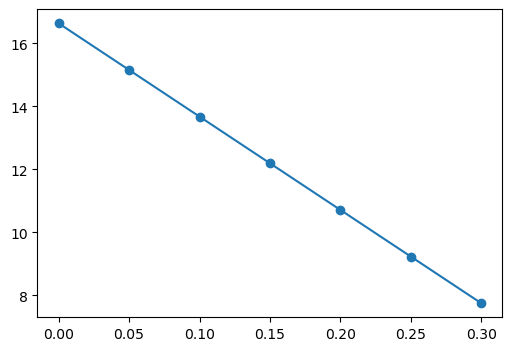

In [77]:
# traffic flux
traffic_fluxes = []
for factor in [0] + factor_list2:
    if factor == 0:
        ds_traffic = xr.open_dataset(f'/gws/nopw/j04/duicv/yuansun/0_urban_traffic/archive/UK-MCR_traffic/lnd/hist/UK-MCR_traffic.clm2.h0.2022-01-01-03600.nc')
        ds_factor_traffic_flux = ds_traffic['TRAFFICFLUX'][8232:8232+168,0]
    else:
        ds_factor = xr.open_dataset(f'/gws/nopw/j04/duicv/yuansun/0_urban_traffic/archive/sensitivity2/0_land_output/UK-MCR_winter2/UK-MCR_winter.clm2.h0.2022-12-10-03600_{factor}.nc')
        ds_factor_traffic_flux = ds_factor['TRAFFICFLUX'][:,0]
    ds_factor_traffic_flux_mean = ds_factor_traffic_flux.mean().item()
    traffic_fluxes.append(ds_factor_traffic_flux_mean)
fig, ax = plt.subplots(figsize=(6,4))   
ax.plot([0] + factor_list2, traffic_fluxes, marker='o')